In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from tensorflow.keras.datasets import cifar10

In [3]:
(x_train,y_train), (x_test,y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1977s 12us/step


In [4]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
plt.imshow(x_train[89])

In [8]:
x_train[0].max()

np.uint8(255)

In [9]:
x_train = x_train / 255

In [10]:
x_test = x_test / 255

In [11]:
x_test.shape

(10000, 32, 32, 3)

In [12]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [13]:
from tensorflow.keras.utils import to_categorical

In [14]:
y_cat_train = to_categorical(y_train,10)

In [15]:
y_cat_test = to_categorical(y_test,10)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

In [17]:
model = Sequential()

model.add(Conv2D(filters=32,kernel_size=(4,4),strides=(1,1),padding="valid",input_shape=(32,32,3),activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=32,kernel_size=(4,4),strides=(1,1),padding="valid",input_shape=(32,32,3),activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(256,activation="relu"))

model.add(Dense(10,activation="softmax"))

model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,610 (881.29 KB)

 Trainable params: 225,610 (881.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
early_stop = EarlyStopping(monitor="val_loss",patience=2)

In [22]:
model.fit(x_train,y_cat_train,epochs=15,validation_data=(x_test,y_cat_test),callbacks=[early_stop])

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 41ms/step - accuracy: 0.4571 - loss: 1.4976 - val_accuracy: 0.5257 - val_loss: 1.3445
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 39ms/step - accuracy: 0.5894 - loss: 1.1584 - val_accuracy: 0.6040 - val_loss: 1.1218
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.6456 - loss: 1.0122 - val_accuracy: 0.6370 - val_loss: 1.0396
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6884 - loss: 0.8965 - val_accuracy: 0.6596 - val_loss: 0.9872
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 53ms/step - accuracy: 0.7188 - loss: 0.8045 - val_accuracy: 0.6800 - val_loss: 0.9332
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.7453 - loss: 0.7287 - val_accuracy: 0.6812 - val_loss: 0.9415
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 41ms/step - accuracy: 0.7731 - loss: 0.6542 - val_accuracy: 0.6867 - val_loss: 0.9528


In [23]:
metrics = pd.DataFrame(model.history.history)

<Axes: >

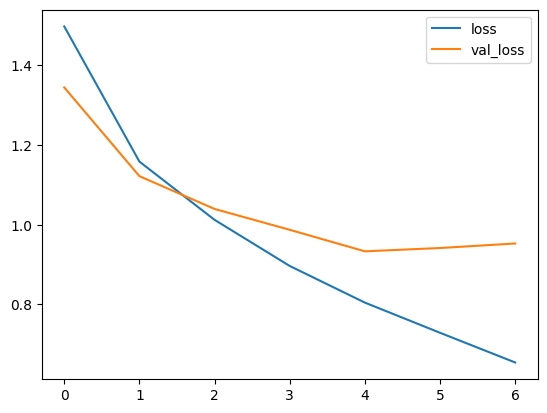

In [24]:
metrics[["loss","val_accuracy"]].plot()

<Axes: >

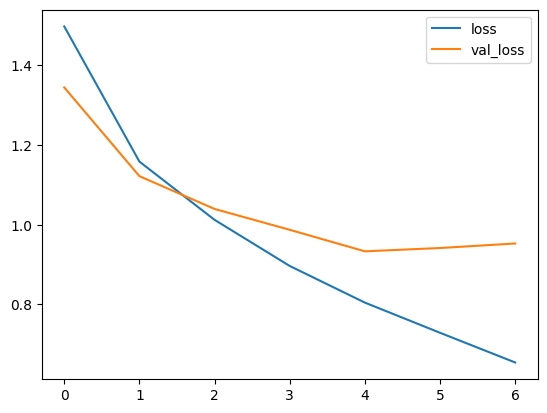

In [25]:
metrics[["loss","val_loss"]].plot()

In [26]:
model.evaluate(x_test,y_cat_test,verbose=0)

[0.952846109867096, 0.6866999864578247]

In [27]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay

In [28]:
predictions = np.argmax(model.predict(x_test),axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [29]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.78      0.67      0.72      1000
           1       0.81      0.77      0.79      1000
           2       0.65      0.52      0.58      1000
           3       0.52      0.47      0.49      1000
           4       0.60      0.67      0.63      1000
           5       0.53      0.67      0.59      1000
           6       0.74      0.80      0.77      1000
           7       0.74      0.74      0.74      1000
           8       0.81      0.77      0.79      1000
           9       0.75      0.78      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



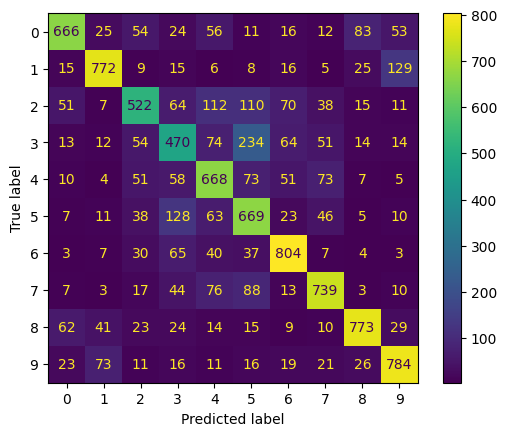

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test,predictions)

In [38]:
my_image = x_test[16]

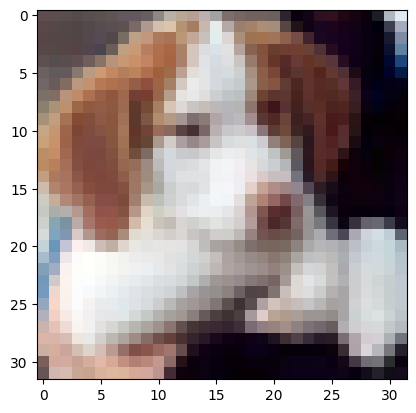

In [39]:
plt.imshow(my_image)

In [40]:
y_test[16]

array([5], dtype=uint8)

In [41]:
np.argmax(model.predict(my_image.reshape(1,32,32,3)),axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([5])